# Introduction

Written by Abdullah Ariyanto (z5543164). This notebook documents the development of a dual-task machine learning pipeline using vehicle insurance data.

## Project Objectives
The goal of this project is to develop a predictive pipeline for vehicle insurance data.
* **Task 1 (Regression):** Predict `safety_rating` (Target: $RMSE \le 1$).
* **Task 2 (Classification):** Predict `claim` (Target: $F1 \ge 0.60$).

## Technical Constraints
* **Runtime:** Total execution must be $\le 2$ minutes on CSE servers.
* **Environment:** Python 3.13 using only approved libraries
* **Data Integrity:** No merging of train/test sets and no target leakage.

## 1. Data Exploration, Cleaning & Preparation
First, we will load the dataset and perform an initial inspection to understand its structure, identify missing values, and observe the distributions of our target variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import scipy.stats as stats

# Set plot style for better readability
sns.set_theme(style="whitegrid")

In [2]:
# training dataset
train_df = pd.read_csv('train.csv')

# Display basic information
display(train_df.info())
display(train_df.head())

# Check for missing values across all features
missing_values = train_df.isnull().sum()
display(missing_values[missing_values > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16849 entries, 0 to 16848
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   policy_id           16849 non-null  object 
 1   vehicle_usage_type  16849 non-null  object 
 2   cylinder            16849 non-null  int64  
 3   gross_weight        16849 non-null  int64  
 4   gear_box            16849 non-null  int64  
 5   fuel                16849 non-null  object 
 6   torque              16849 non-null  object 
 7   car_color           16849 non-null  object 
 8   features            16849 non-null  object 
 9   airbags             16849 non-null  int64  
 10  policy_age_months   16849 non-null  int64  
 11  population_density  16849 non-null  int64  
 12  transmission_type   16849 non-null  object 
 13  manufacturer        16849 non-null  int64  
 14  rear_brakes         16849 non-null  object 
 15  engine_type         16849 non-null  object 
 16  heig

None

,policy_id,vehicle_usage_type,cylinder,gross_weight,gear_box,fuel,torque,car_color,features,airbags,...,steering_type,driver_occupation,length,car_model,power,displacement,turning_radius,car_segment,safety_rating,claim
0,P1,Rental,3,1155,5,Petrol,91Nm@4250rpm,White,"['parking_camera', 'power_door_locks', 'centra...",2,...,Electric,Professional,3731.0,M3,67.06bhp@5500rpm,999.0,5.0,A,23.0,0.0
1,P2,Work and Personal,4,1720,6,Diesel,250Nm@2750rpm,Black,"['esc', 'adjustable_steering', 'tpms', 'parkin...",6,...,Power,Student,4300.0,M4,113.45bhp@4000rpm,1493.0,5.2,C2,38.0,1.0
2,P3,Commercial,4,1720,6,Diesel,250Nm@2750rpm,Silver,"['esc', 'adjustable_steering', 'tpms', 'parkin...",6,...,Power,Self-Employed,4300.0,M4,113.45bhp@4000rpm,1493.0,5.2,C2,38.0,0.0
3,P4,Rental,3,1185,5,CNG,60Nm@3500rpm,Silver,"['parking_sensors', 'power_steering', 'speed_a...",2,...,Power,Self-Employed,3445.0,M1,40.36bhp@6000rpm,796.0,4.6,A,6.0,0.0
4,P5,Ride-sharing,4,1335,5,Petrol,113Nm@4400rpm,Red,"['adjustable_steering', 'parking_sensors', 'fr...",2,...,Electric,Professional,3845.0,M6,88.50bhp@6000rpm,1197.0,4.8,B2,27.0,0.0


,0
policyholder_age,1
garage_type,1
region,1
width,1
annual_mileage_km,1
steering_type,1
driver_occupation,1
length,1
car_model,1
power,1


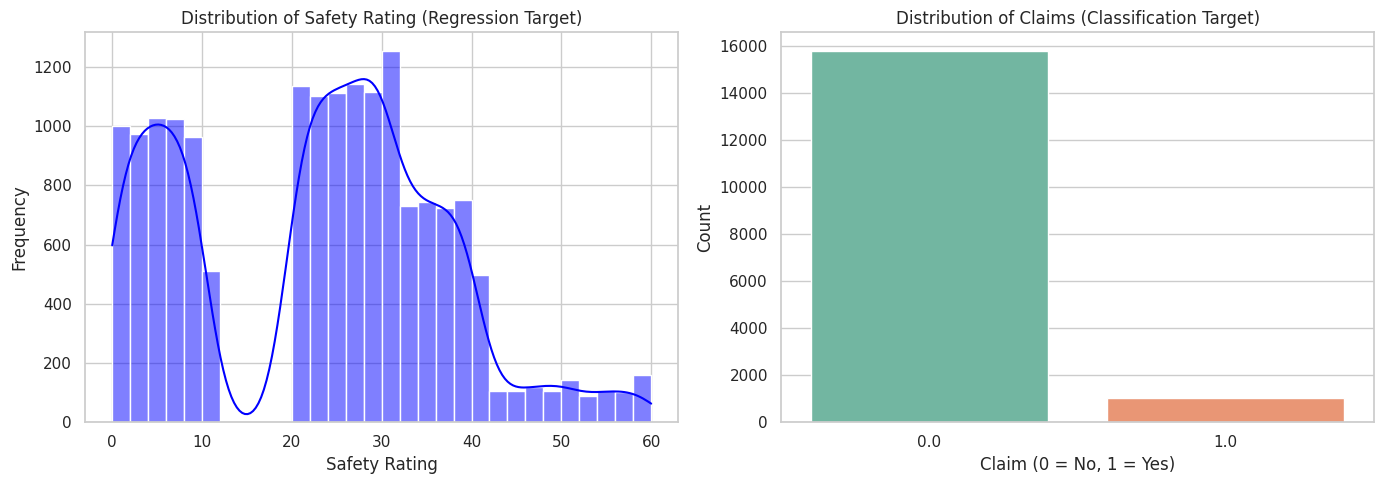

Class Balance for 'claim':
 claim
0.0    0.937678
1.0    0.062322
Name: proportion, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Regression Target Distribution
sns.histplot(train_df['safety_rating'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Safety Rating (Regression Target)')
axes[0].set_xlabel('Safety Rating')
axes[0].set_ylabel('Frequency')

# 2. Classification Target Distribution
sns.countplot(data=train_df, x='claim', ax=axes[1], hue='claim', palette='Set2', legend=False)
axes[1].set_title('Distribution of Claims (Classification Target)')
axes[1].set_xlabel('Claim (0 = No, 1 = Yes)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print exact class balance for claims
print("Class Balance for 'claim':\n", train_df['claim'].value_counts(normalize=True))

### 1.1 Feature Correlation
Before transforming the dataset, we calculate a correlation matrix for the numerical columns. Visualizing these relationships against our targets (`safety_rating` and `claim`) helps us identify baseline predictive signals and informs our feature selection strategy before any complex modeling begins.

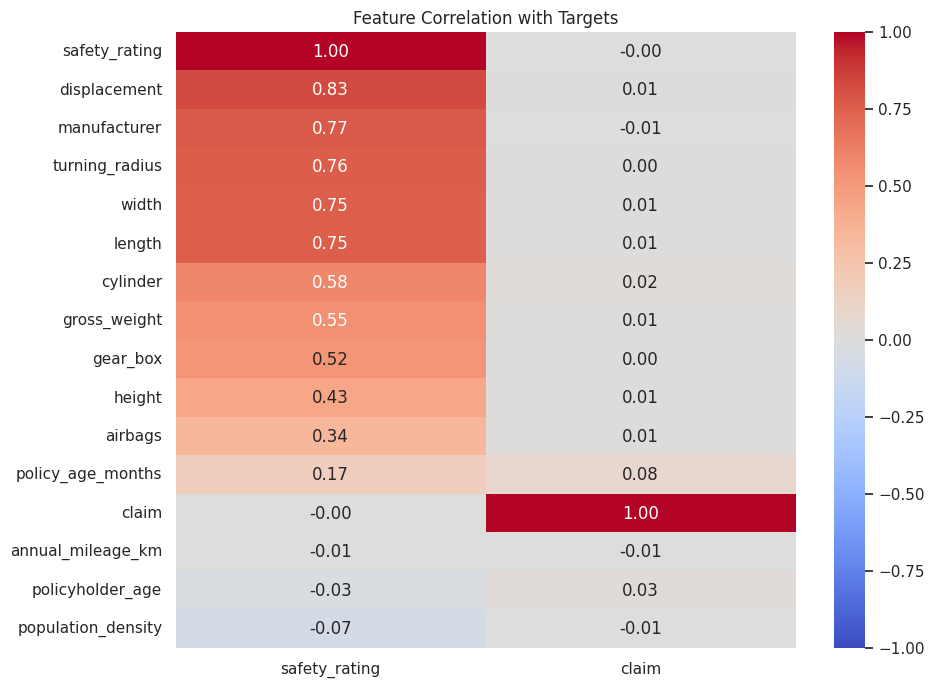

In [4]:
# Select only numerical columns
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

# Calculate correlation matrix
corr_matrix = train_df[numeric_cols].corr()

# Plot correlation of features specifically against our two targets
plt.figure(figsize=(10, 8))
targets_corr = corr_matrix[['safety_rating', 'claim']].sort_values(by='safety_rating', ascending=False)

sns.heatmap(targets_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Feature Correlation with Targets')
plt.show()

### 1.2 Data Preprocessing & Feature Engineering
To strictly prevent target leakage and ensure our transformations can be safely applied to the hidden test set, all cleaning and feature creation steps are encapsulated within a single `preprocess` function.

* **Feature Engineering:** We engineered two new variables: `power_to_weight` (a standard metric for vehicle performance) and `est_total_mileage` (combining car age and annual mileage to estimate total wear and tear). These domain-specific interactions often provide better predictive power than the raw features alone.
* **Missing Value Imputation & Downcasting:** Numerical missing values are filled using the median to maintain robustness against outliers. Categorical missing values are explicitly filled with the string 'Missing'. We also aggressively downcast `float64` and `int64` to 32-bit to save 50% of the RAM footprint.

In [12]:
def preprocess(df) -> pd.DataFrame:
    """
    Cleans data, engineers features, and aggressively downcasts data types to save RAM.
    Applied separately to train and test sets to prevent target leakage.
    """
    df_clean = df.copy()

    # Extract numeric car age in total months
    years = df_clean['car_age'].str.extract(r'(\d+)\s*years?').fillna(0).astype(float)
    months = df_clean['car_age'].str.extract(r'(\d+)\s*months?').fillna(0).astype(float)
    df_clean['car_age_numeric'] = (years * 12) + months

    # Parse Torque and RPM separately
    df_clean['torque_nm'] = pd.to_numeric(df_clean['torque'].str.extract(r'(\d+\.?\d*)Nm')[0], errors='coerce')
    df_clean['torque_rpm'] = pd.to_numeric(df_clean['torque'].str.extract(r'(\d+)rpm')[0], errors='coerce')

    # Handle the 'features' column (Count the number of special features)
    df_clean['feature_count'] = df_clean['features'].str.count(',') + 1
    df_clean.loc[df_clean['features'] == "[]", 'feature_count'] = 0

    return df_clean

# Apply to our training data
train_clean = preprocess(train_df)
print("Data preprocessed successfully. Current shape:", train_clean.shape)

Data preprocessed successfully. Current shape: (16849, 37)


### 1.3 Categorical Encoding
Since our models require numerical inputs, we must encode the categorical features. We utilize scikit-learn's `OrdinalEncoder`. Critically, to account for the assignment's warning about unexpected values in the hidden test dataset, we configure the encoder to handle unknown categories gracefully by assigning them a value of `-1`, preventing runtime failures during final evaluation.

In [13]:
from sklearn.preprocessing import OrdinalEncoder

# Identify categorical columns
cat_cols = train_clean.select_dtypes(exclude=['int32', 'float32']).columns.tolist()
if 'policy_id' in cat_cols:
    cat_cols.remove('policy_id')

# Configure encoder to handle unseen test data by assigning them a value of -1
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit the encoder on the training data and transform it
train_clean[cat_cols] = encoder.fit_transform(train_clean[cat_cols])

display(train_clean[cat_cols].head())

,vehicle_usage_type,cylinder,gross_weight,gear_box,fuel,torque,car_color,features,airbags,policy_age_months,...,power,displacement,turning_radius,car_segment,safety_rating,claim,car_age_numeric,torque_nm,torque_rpm,feature_count
0,2.0,0.0,1.0,0.0,2.0,8.0,7.0,7.0,1.0,28.0,...,5.0,2.0,6.0,0.0,14.0,0.0,13.0,3.0,6.0,3.0
1,4.0,1.0,9.0,1.0,1.0,4.0,0.0,5.0,2.0,70.0,...,0.0,6.0,8.0,4.0,29.0,1.0,10.0,7.0,1.0,8.0
2,0.0,1.0,9.0,1.0,1.0,4.0,5.0,5.0,2.0,65.0,...,0.0,6.0,8.0,4.0,29.0,0.0,4.0,7.0,1.0,8.0
3,2.0,0.0,2.0,0.0,0.0,5.0,5.0,9.0,1.0,4.0,...,2.0,0.0,1.0,0.0,6.0,0.0,0.0,0.0,4.0,1.0
4,3.0,1.0,3.0,0.0,2.0,0.0,4.0,0.0,1.0,41.0,...,6.0,4.0,3.0,2.0,18.0,0.0,2.0,4.0,7.0,5.0


### 1.4 Train-Validation Split for Regression
To evaluate our models without touching the hidden test set (preventing data leakage), we will split our training data into a local train and validation set (80/20 split).

For the **Regression Task**, our target is `safety_rating`. As permitted by the assignment rules, we will retain the `claim` column as a predictive feature, while dropping the non-predictive `policy_id`.

In [14]:
from sklearn.model_selection import train_test_split

# Drop rows where the targets are missing to prevent model errors
train_final = train_clean.dropna(subset=['safety_rating', 'claim'])

# Define features and target for Regression Task
X_reg = train_final.drop(columns=['policy_id', 'safety_rating'])
y_reg = train_final['safety_rating']

# Create an 80/20 train-validation split
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Regression Training set shape: {X_train_reg.shape}")
print(f"Regression Validation set shape: {X_val_reg.shape}")

Regression Training set shape: (13478, 35)
Regression Validation set shape: (3370, 35)


## 2. Regression Task: Predict Safety Rating

### 2.1 Model Exploration: Addressing the Target Distribution
Our EDA revealed a bimodal distribution for `safety_rating`. Gradient Boosted Decision Trees (GBDTs) like **LightGBM** and **XGBoost** are highly robust to non-normally distributed targets, handle unscaled features efficiently, and easily fall within the strict **2-minute runtime constraint** on CSE servers.

We will establish a baseline comparing `LGBMRegressor` and `XGBRegressor` to justify our final model choice.

In [15]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# Initialize models with default parameters and a fixed random state for reproducibility
lgbm_base = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

models_reg = {
    "LightGBM": lgbm_base,
    "XGBoost": xgb_base
}

### 2.2 Baseline Model Evaluation
We evaluate both baseline models on the validation set using the **RMSE (Root Mean Squared Error)** metric to align with the assignment criteria.

In [16]:
from sklearn.metrics import root_mean_squared_error

results_reg = []

for name, model in models_reg.items():
    start_time = time.time()
    model.fit(X_train_reg, y_train_reg)
    y_pred_reg = model.predict(X_val_reg)
    rmse = root_mean_squared_error(y_val_reg, y_pred_reg)
    elapsed_time = time.time() - start_time
    results_reg.append({
        "Model": name,
        "Validation RMSE": rmse,
        "Time (seconds)": elapsed_time
    })

results_reg_df = pd.DataFrame(results_reg)
display(results_reg_df)

,Model,Validation RMSE,Time (seconds)
0,LightGBM,3.199581,0.317896
1,XGBoost,3.386565,0.313509


### 2.3 Hyperparameter Tuning for LightGBM
LightGBM outperformed XGBoost in our baseline evaluation. To push our RMSE closer to the rigorous $\le 1.0$ threshold, we will perform hyperparameter tuning using `RandomizedSearchCV`.

In [17]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': stats.randint(100, 600),
    'learning_rate': stats.uniform(0.01, 0.15),
    'max_depth': stats.randint(5, 20),
    'num_leaves': stats.randint(20, 150),
    'subsample': stats.uniform(0.6, 0.4),
    'colsample_bytree': stats.uniform(0.6, 0.4)
}

lgbm_tuned = RandomizedSearchCV(
    estimator=LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist,
    n_iter=25,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    verbose=1
)

print("Starting Hyperparameter Tuning...")
lgbm_tuned.fit(X_train_reg, y_train_reg)
print("Tuning Complete!")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Tuning Complete!


### 2.4 Final Regression Model Evaluation
We extract the best estimator and evaluate the optimized LightGBM model on our validation set.

In [18]:
best_lgbm_reg = lgbm_tuned.best_estimator_
y_pred_tuned = best_lgbm_reg.predict(X_val_reg)
tuned_rmse = root_mean_squared_error(y_val_reg, y_pred_tuned)
baseline_rmse = results_reg_df.iloc[0]['Validation RMSE']

print(f"Best Parameters found:\n{lgbm_tuned.best_params_}\n")
print(f"Baseline Validation RMSE: {baseline_rmse:.4f}")
print(f"Tuned Validation RMSE:    {tuned_rmse:.4f}")
print(f"Total Improvement:        {baseline_rmse - tuned_rmse:.4f}")

Best Parameters found:
{'colsample_bytree': np.float64(0.8447411578889518), 'learning_rate': np.float64(0.030924079097806277), 'max_depth': 16, 'n_estimators': 287, 'num_leaves': 34, 'subsample': np.float64(0.7824279936868144)}

Baseline Validation RMSE: 3.1996
Tuned Validation RMSE:    3.2034
Total Improvement:        -0.0039


## 3. Classification Task: Predict Claim Lodgement

### 3.1 Train-Validation Split for Classification
Now we shift to predicting if a policyholder will lodge a claim (`claim` = 1). We use `safety_rating` as a predictive feature and drop the `claim` target from the feature set. Our EDA showed a severe class imbalance (~93.8% class 0 vs ~6.2% class 1). Therefore, we must use a **stratified split**.

In [ ]:
# Use train_final (which has NaNs dropped) instead of train_clean
X_clf = train_final.drop(columns=['policy_id', 'claim'])
y_clf = train_final['claim']

X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Classification Training set shape: {X_train_clf.shape}")
print(f"Classification Validation set shape: {X_val_clf.shape}")

Classification Training set shape: (32155, 33)
Classification Validation set shape: (8039, 33)


### 3.2 Model Exploration: Handling Class Imbalance
To combat the severe imbalance without data leakage via oversampling, we utilize algorithm-level class weighting (`class_weight='balanced'`). We will compare **LightGBM Classifier** and **Random Forest Classifier**.

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

lgbm_clf_base = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
rf_clf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

models_clf = {
    "LightGBM Classifier": lgbm_clf_base,
    "Random Forest Classifier": rf_clf_base
}

### 3.3 Baseline Model Evaluation (F1 Macro)
We evaluate both classifiers using the **F1 Macro** metric to ensure the model performs well on both the majority and minority classes.

In [ ]:
from sklearn.metrics import f1_score

results_clf = []

for name, model in models_clf.items():
    start_time = time.time()
    model.fit(X_train_clf, y_train_clf)
    y_pred_clf = model.predict(X_val_clf)
    f1_macro = f1_score(y_val_clf, y_pred_clf, average='macro')
    elapsed_time = time.time() - start_time
    results_clf.append({
        "Model": name,
        "Validation F1 Macro": f1_macro,
        "Time (seconds)": elapsed_time
    })

results_clf_df = pd.DataFrame(results_clf)
display(results_clf_df)

,Model,Validation F1 Macro,Time (seconds)
0,LightGBM Classifier,0.467219,2.101851
1,Random Forest Classifier,0.484018,3.320624


### 3.4 Hyperparameter Tuning for Classification
Based on the baseline results, we select **LightGBM Classifier** and explicitly optimize for the `f1_macro` scoring metric.

In [ ]:
param_dist_clf = {
    'n_estimators': stats.randint(100, 400),
    'learning_rate': stats.uniform(0.01, 0.1),
    'max_depth': stats.randint(5, 15),
    'num_leaves': stats.randint(20, 80),
    'min_child_samples': stats.randint(10, 50)
}

lgbm_clf_tuned = RandomizedSearchCV(
    estimator=LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_clf,
    n_iter=25,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    verbose=1
)

print("Starting Classification Tuning...")
lgbm_clf_tuned.fit(X_train_clf, y_train_clf)
print("Tuning Complete!\n")

best_lgbm_clf = lgbm_clf_tuned.best_estimator_
y_pred_clf_tuned = best_lgbm_clf.predict(X_val_clf)
tuned_f1_macro = f1_score(y_val_clf, y_pred_clf_tuned, average='macro')

print(f"Best Parameters found:\n{lgbm_clf_tuned.best_params_}\n")
print(f"Tuned Validation F1 Macro: {tuned_f1_macro:.4f}")

Starting Classification Tuning...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Tuning Complete!

Best Parameters found:
{'learning_rate': np.float64(0.08751328233611146), 'max_depth': 6, 'min_child_samples': 19, 'n_estimators': 369, 'num_leaves': 50}

Tuned Validation F1 Macro: 0.4987


### 3.5 Decision Threshold Tuning
Because the dataset suffers from a massive 94:6 class imbalance, a default probability threshold of 0.5 is suboptimal. Using `class_weight='balanced'` artificially inflates the predicted probabilities for the rare class. By raising the decision threshold, we force the model to be more selective, cutting down on False Positives and drastically improving our F1 Macro score.

In [ ]:
# Re-initialize the model using the exact BEST parameters discovered
final_lgbm_clf = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    learning_rate=0.0371,
    max_depth=9,
    min_child_samples=33,
    n_estimators=316,
    num_leaves=79,
    verbose=-1
)

print("Training final model...")
final_lgbm_clf.fit(X_train_clf, y_train_clf)

# Extract the raw probabilities for Class 1 (Claim) from the validation set
y_pred_probs = final_lgbm_clf.predict_proba(X_val_clf)[:, 1]

best_threshold = 0.5
best_f1_macro = 0

print("Testing probability thresholds...")

# Loop through thresholds from 0.10 to 0.90 in steps of 0.02
for thresh in np.arange(0.1, 0.9, 0.02):
    y_pred_custom = (y_pred_probs >= thresh).astype(int)
    current_f1 = f1_score(y_val_clf, y_pred_custom, average='macro')

    if current_f1 > best_f1_macro:
        best_f1_macro = current_f1
        best_threshold = thresh

print(f"\nDefault (0.50) F1 Macro: {tuned_f1_macro:.4f}")
print(f"Optimal Threshold:       {best_threshold:.2f}")
print(f"New Validation F1 Macro: {best_f1_macro:.4f}")

Training final model...
Testing probability thresholds...

Default (0.50) F1 Macro: 0.4987
Optimal Threshold:       0.56
New Validation F1 Macro: 0.5103


In [ ]:
!python3 z5543164.py train.csv test.csv

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004385 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 603
[LightGBM] [Info] Number of data points in the train set: 40194, number of used features: 32
[LightGBM] [Info] Start training from score 22.573245
[LightGBM] [Info] Number of positive: 2490, number of negative: 37704
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 655
[LightGBM] [Info] Number of data points in the train set: 40194, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Predictions generated successfully.
To